# Этап 3. Создание целевой переменной

**Цель этапа:** создать метки  для каждого блюда — "нужна ли замена" под каждую из 4 целей пользователя.

** цели пользователя:**
1. Похудение
2. Набор массы
3. Баланс/ЗОЖ
4. Контроль сахара

## 1. Загрузка данных

In [71]:
import csv
import pandas as pd

def load_and_fix_csv(path):
    with open(path, 'r', encoding='utf-8') as f:
        reader = csv.reader(f)
        header = next(reader)
        n_cols = len(header)
        fixed_rows = []
        for row in reader:
            if len(row) == n_cols:
                fixed_rows.append(row)
            else:
                print('Неожиданная строка, пропущена:', row)
    return pd.DataFrame(fixed_rows, columns=header)

df = load_and_fix_csv('../data/russian_food_dataset.csv')


numeric_cols = ['Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)', 'Fiber (g)', 'Sugars (g)', 'Sodium (mg)']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])


print('Данные загружены:', df.shape)

Данные загружены: (400, 10)


## 2. Вычисление порогов через перцентили

Для каждого числового признака вычисляем:
- **75-й перцентиль** — граница "высокого" значения (верхние 25% блюд)
- **25-й перцентиль** — граница "низкого" значения (нижние 25% блюд)

In [72]:
features = ['Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)',
            'Fat (g)', 'Sugars (g)', 'Sodium (mg)']

# 75-й перцентиль = порог "высокого" значения, 25-й = порог "низкого".
# Считаем отдельно по каждому Meal_Type (см. вывод из EDA).
q_high = df.groupby('Meal_Type')[features].transform(
    lambda x: x.quantile(0.75)
)
q_high.columns = [f'{c}_high' for c in features]

q_low = df.groupby('Meal_Type')[features].transform(
    lambda x: x.quantile(0.25)
)
q_low.columns = [f'{c}_low' for c in features]

## 3. Создание целевых переменных

Правила разметки:
- **Похудение:** калории высокие или сахар высокий или жиры высокие
- **Набор массы:** калории низкие или белок низкий или углеводы низкие
- **Баланс:** сахар высокий или натрий высокий
- **Контроль сахара:** сахар высокий или углеводы высокие

In [73]:
# 1. Похудение
df['target_weightloss'] = (
    (df['Calories (kcal)'] > q_high['Calories (kcal)_high']) |
    (df['Sugars (g)']      > q_high['Sugars (g)_high'])      |
    (df['Fat (g)']         > q_high['Fat (g)_high'])
).astype(int)

# 2. Набор массы — условие ИЛИ (достаточно одного из трёх критериев)
df['target_gainmass'] = (
    (df['Calories (kcal)']   < q_low['Calories (kcal)_low'])   |
    (df['Protein (g)']       < q_low['Protein (g)_low'])       |
    (df['Carbohydrates (g)'] < q_low['Carbohydrates (g)_low'])
).astype(int)

# 3. Баланс/ЗОЖ
df['target_balance'] = (
    (df['Sugars (g)']  > q_high['Sugars (g)_high']) |
    (df['Sodium (mg)'] > q_high['Sodium (mg)_high'])
).astype(int)

# 4. Контроль сахара
df['target_sugar'] = (
    (df['Sugars (g)']        > q_high['Sugars (g)_high'])        |
    (df['Carbohydrates (g)'] > q_high['Carbohydrates (g)_high'])
).astype(int)

targets = ['target_weightloss', 'target_gainmass', 'target_balance', 'target_sugar']
labels  = ['Похудение', 'Набор массы', 'Баланс/ЗОЖ', 'Контроль сахара']

print('Целевые переменные созданы')
print()

for target, label in zip(targets, labels):
    count_1 = df[target].sum()
    count_0 = len(df) - count_1
    pct = round(count_1 / len(df) * 100)
    print(f'{label}: нужна замена — {count_1} ({pct}%), не нужна — {count_0} ({100-pct}%)')

Целевые переменные созданы

Похудение: нужна замена — 174 (44%), не нужна — 226 (56%)
Набор массы: нужна замена — 179 (45%), не нужна — 221 (55%)
Баланс/ЗОЖ: нужна замена — 152 (38%), не нужна — 248 (62%)
Контроль сахара: нужна замена — 138 (34%), не нужна — 262 (66%)


## 4. Визуализация баланса классов

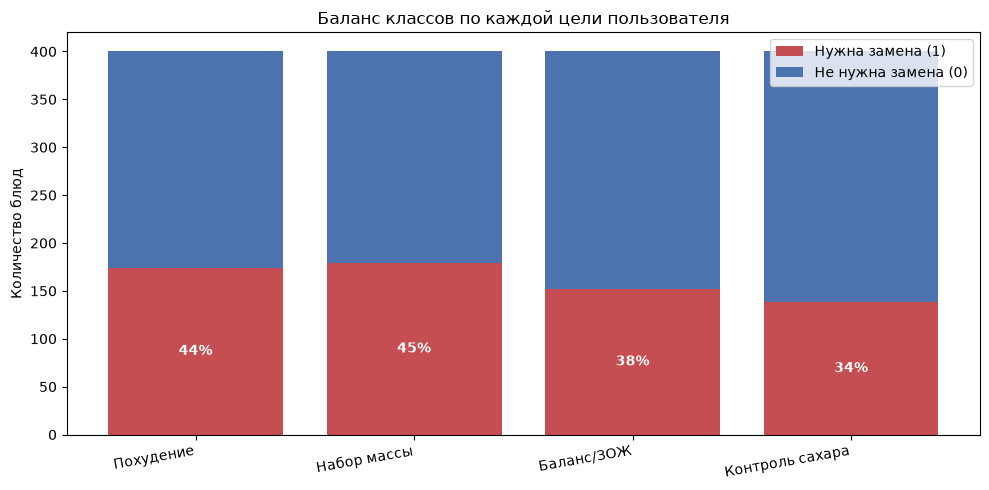

In [74]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

counts_need   = [df[t].sum() for t in targets]
counts_noneed = [len(df) - df[t].sum() for t in targets]
x = range(len(labels))

ax.bar(x, counts_need,   label='Нужна замена (1)',    color='#C44E52')
ax.bar(x, counts_noneed, label='Не нужна замена (0)', color='#4C72B0',
       bottom=counts_need)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=10, ha='right')
ax.set_ylabel('Количество блюд')
ax.set_title('Баланс классов по каждой цели пользователя')
ax.legend()

for i, (c1, c0) in enumerate(zip(counts_need, counts_noneed)):
    pct = round(c1 / len(df) * 100)
    ax.text(i, c1 / 2, f'{pct}%', ha='center', va='center',
            color='white', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Пример размеченных данных

In [75]:
cols_show = ['Food_Item', 'Calories (kcal)', 'Sugars (g)', 'Fat (g)', 'Protein (g)',
             'target_weightloss', 'target_gainmass', 'target_balance', 'target_sugar']
df[cols_show].head(10)

,Food_Item,Calories (kcal),Sugars (g),Fat (g),Protein (g),target_weightloss,target_gainmass,target_balance,target_sugar
0,Борщ,50,2.0,2.0,2.8,0,1,0,0
1,Щи из свежей капусты,35,1.5,1.2,2.0,0,1,0,0
2,Щи из квашеной капусты,40,0.5,1.5,2.2,0,1,1,0
3,Рассольник,55,0.5,2.5,3.5,0,1,1,0
4,Солянка мясная,98,1.0,6.0,6.5,0,1,1,0
5,Уха,45,0.5,1.5,5.0,0,1,0,0
6,Окрошка на кефире,42,1.5,1.5,3.2,0,1,0,0
7,Гороховый суп,115,1.0,3.5,7.5,0,0,1,0
8,Куриный бульон,25,0.2,1.0,3.0,0,1,0,0
9,Грибной суп,38,1.0,1.2,2.5,0,1,0,0


## 6. Сохранение датасета с метками

In [76]:
df.to_csv('../data/russian_food_labeled.csv', index=False)
print('Файл сохранён: data/russian_food_labeled.csv')
print('Размер:', df.shape)
print('Целевые столбцы:', [c for c in df.columns if c.startswith('target_')])

Файл сохранён: data/russian_food_labeled.csv
Размер: (400, 14)
Целевые столбцы: ['target_weightloss', 'target_gainmass', 'target_balance', 'target_sugar']


## 7. Выводы по Этапу 3

1. Создано 4 целевые переменные (`target_weightloss`, `target_gainmass`, `target_balance`, `target_sugar`).
2. Пороги "высокое/низкое" — фиксированные 75-й и 25-й перцентили, посчитанные
   **отдельно для каждого `Meal_Type`** (учитывает разницу в калорийности между
   завтраком, обедом и перекусом). Пороги не подбирались под конкретный баланс
   классов.
3. Размеченный датасет сохранён в `data/russian_food_labeled.csv`.